# Coal gasification + HB + CCS ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for Coal gasification + HB + CCS at 1,000,000 tNH3/year. The notebook shows NPV, LNM, and LCOA distributions, NPV sign counts, and mean annual cost components. The CCS increment is resolved against Coal gasification + HB. The notebook shows both parent inputs and incremental changes; transport and storage follow the shared CCS cost rule.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "coal_gasification_hb_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,bau_variable_opex_eur_per_tnh3,bau_coal_consumption_mwh_per_tnh3,bau_electricity_consumption_mwh_per_tnh3,bau_emissions_tco2_per_tnh3,capex_change_eur_per_tnh3,fixed_opex_change_eur_per_tnh3,variable_opex_change_eur_per_tnh3,coal_consumption_change_mwh_per_tnh3,electricity_consumption_change_mwh_per_tnh3,emissions_reduction_fraction
0,0,coal_gasification_hb_ccs,retrofit,sampled,"1,000,000.000",25,"3,925.862",159.353,18.749,coal,...,18.749,9.360,1.030,3.200,215.000,34.000,0.000,0.000,0.333,0.900
1,1,coal_gasification_hb_ccs,retrofit,sampled,"1,000,000.000",25,"3,126.682",152.185,15.385,coal,...,15.385,9.360,1.030,3.200,215.000,34.000,0.000,0.000,0.333,0.900
2,2,coal_gasification_hb_ccs,retrofit,sampled,"1,000,000.000",25,"2,964.548",141.988,15.833,coal,...,15.833,9.360,1.030,3.200,215.000,34.000,0.000,0.000,0.333,0.900
3,3,coal_gasification_hb_ccs,retrofit,sampled,"1,000,000.000",25,"3,733.263",141.280,16.888,coal,...,16.888,9.360,1.030,3.200,215.000,34.000,0.000,0.000,0.333,0.900
4,4,coal_gasification_hb_ccs,retrofit,sampled,"1,000,000.000",25,"3,570.594",152.844,16.090,coal,...,16.090,9.360,1.030,3.200,215.000,34.000,0.000,0.000,0.333,0.900


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_net_margin_eur_per_tnh3 = results["levelized_net_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,974.541,91.294,798.706
std,554.850,51.978,51.978
min,"-1,375.279",-128.834,619.864
5%,47.434,4.444,714.539
50%,981.861,91.980,798.020
95%,"1,873.011",175.461,885.556
max,"2,883.646",270.136,"1,018.834"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),95836,0.958
1,Negative (NPV < 0),4164,0.042


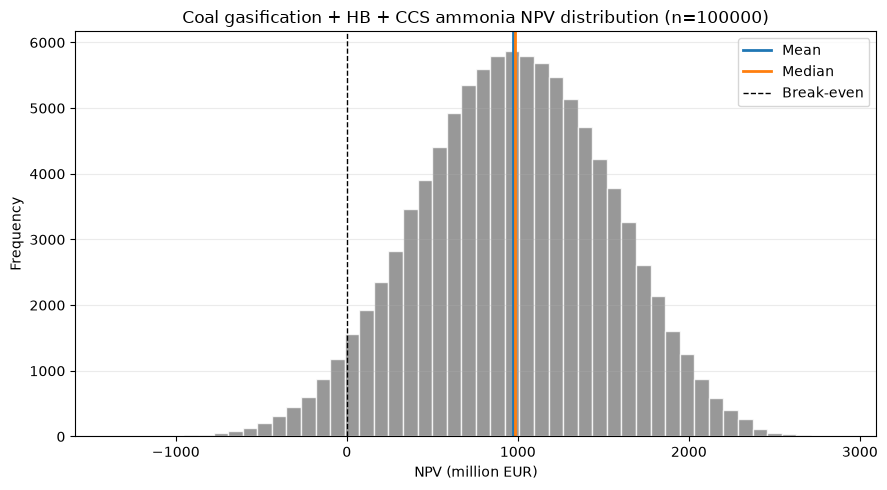

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Coal gasification + HB + CCS ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

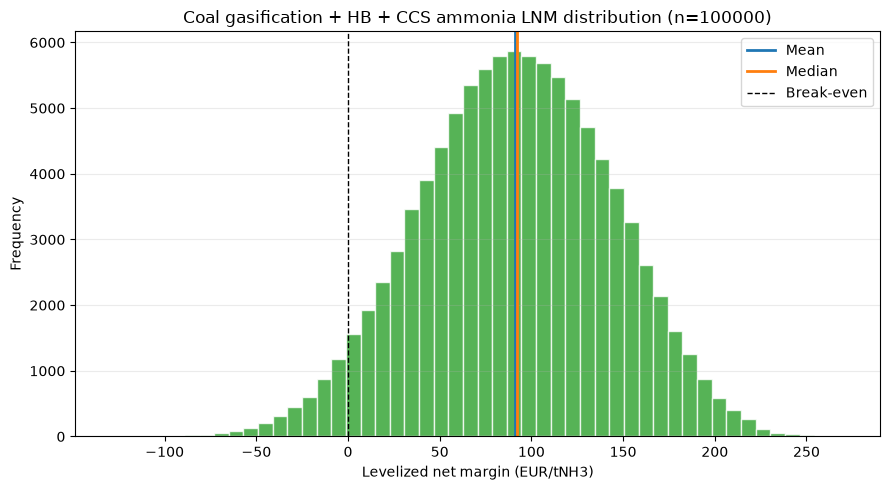

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tnh3,
    title=f"Coal gasification + HB + CCS ammonia LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

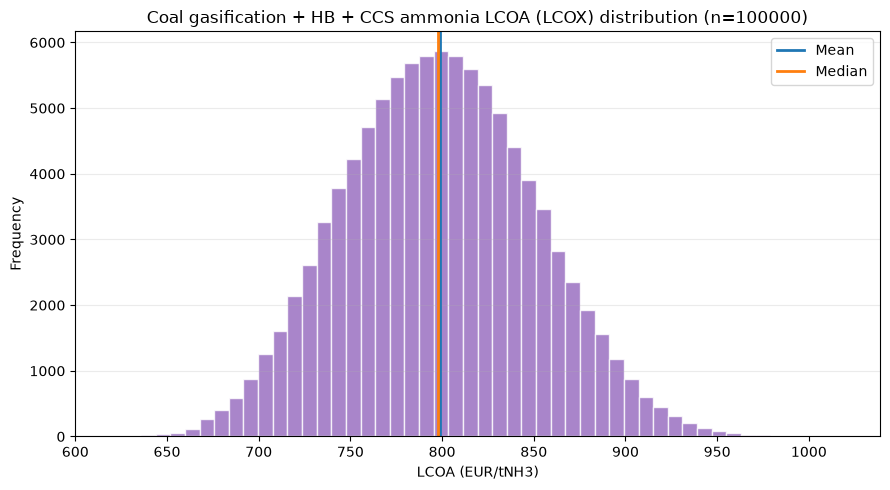

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"Coal gasification + HB + CCS ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      890.000
annual_fixed_opex_eur                   150.947
annual_variable_opex_eur                 16.766
annual_natural_gas_cost_eur               0.000
annual_coal_cost_eur                    113.362
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    113.362
annual_electricity_cost_eur             158.933
annual_transport_and_storage_cost_eur    17.385
annual_emissions_cost_eur                25.600
annual_net_cash_flow_eur                407.007
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    column for column in results
    if column.startswith("bau_") or "_change_" in column
    or column == "emissions_reduction_fraction"
]
results[retrofit_columns].describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
bau_capex_eur_per_tnh3,"100,000.000","3,155.173",314.464,"2,442.212","2,658.070","3,133.978","3,707.292","3,965.584"
bau_fixed_opex_eur_per_tnh3,"100,000.000",116.947,11.523,91.071,98.846,116.088,137.307,146.944
bau_variable_opex_eur_per_tnh3,"100,000.000",16.766,1.667,13.010,14.140,16.641,19.697,21.073
bau_coal_consumption_mwh_per_tnh3,"100,000.000",9.360,0.000,9.360,9.360,9.360,9.360,9.360
bau_electricity_consumption_mwh_per_tnh3,"100,000.000",1.030,0.000,1.030,1.030,1.030,1.030,1.030
bau_emissions_tco2_per_tnh3,"100,000.000",3.200,0.000,3.200,3.200,3.200,3.200,3.200
capex_change_eur_per_tnh3,"100,000.000",215.000,0.000,215.000,215.000,215.000,215.000,215.000
fixed_opex_change_eur_per_tnh3,"100,000.000",34.000,0.000,34.000,34.000,34.000,34.000,34.000
variable_opex_change_eur_per_tnh3,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
coal_consumption_change_mwh_per_tnh3,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
